# Dense Layer Backpropagation

Trong notebook này chúng ta sẽ:

1. Hiểu gradient là gì.
2. Tính đạo hàm của Dense Layer.
3. Cài đặt backward().
4. Kiểm tra gradient bằng ví dụ số.
5. Thực hiện một bước Gradient Descent.

Sau notebook này chúng ta sẽ hiểu chính xác cách Neural Network học.

In [1]:
import sys
import os

sys.path.append("..")

import numpy as np

from src.dense import Dense

In [3]:
x = np.array([
    1.0,
    2.0,
    3.0
])

dense = Dense(
    input_dim=3,
    output_dim=2
)

dense.weights = np.array([
    [0.1,0.2,0.3],
    [0.4,0.5,0.6]
])

dense.bias = np.array([
    0.1,
    0.2
])

y = dense.forward(x)

print(y)

[1.5 3.4]


In [4]:
expected = np.array([
    0.1*1 + 0.2*2 + 0.3*3 + 0.1,
    0.4*1 + 0.5*2 + 0.6*3 + 0.2
])

print(expected)

[1.5 3.4]


### Backpropagation intuition

Giả sử:

Loss = L

Dense Output = y

Input = x

Ta đã biết:

dL/dy

Mục tiêu:

1. dL/dW
2. dL/db
3. dL/dx

### Đạo hàm theo Bias
Bias: 
$$y = Wx + b$$

Do:
$$\frac {\partial y} {\partial b} = 1$$

Nên:
$$\frac {\partial L} {\partial b} = \frac {\partial L} {\partial y}$$

In [5]:
grad_output = np.array([
    2.0,
    3.0
])

db = grad_output

print(db)

[2. 3.]


### Đạo hàm theo Weights
Dense:
$$y_i = \sum_j W_{ij} x_j + b_i$$

Do đó:
$$\frac {\partial y_i} {\partial W_{ij}} = x_j$$

Suy ra:
$$dW = \text{grad output} \otimes x$$

Outer Product.

In [6]:
x = np.array([
    1,
    2,
    3
])

grad_output = np.array([
    2,
    3
])

dW = np.outer(
    grad_output,
    x
)

print(dW)

[[2 4 6]
 [3 6 9]]


### Đạo hàm theo input
để truyền gradient về layer trước:
$$dX = W^T dY$$

In [7]:
W = np.array([
    [0.1,0.2,0.3],
    [0.4,0.5,0.6]
])

grad_output = np.array([
    2,
    3
])

dx = W.T @ grad_output

print(dx)

manual = np.array([
    0.1*2 + 0.4*3,
    0.2*2 + 0.5*3,
    0.3*2 + 0.6*3
])

print(manual)

[1.4 1.9 2.4]
[1.4 1.9 2.4]


In [9]:
# Test Dense Backward
dense = Dense(
    input_dim=3,
    output_dim=2
)

x = np.array([
    1.0,
    2.0,
    3.0
])

dense.forward(x)

grad_output = np.array([
    2.0,
    3.0
])

grad_input = dense.backward(
    grad_output
)

In [10]:
print("dW")
print(dense.dW)

print()

print("db")
print(dense.db)

print()

print("grad_input")
print(grad_input)

dW
[[2. 4. 6.]
 [3. 6. 9.]]

db
[2. 3.]

grad_input
[-0.63510803 -2.78865409  3.46472849]


In [11]:
# Quan sát loss
x = np.array([
    1.0,
    2.0
])

target = np.array([
    1.0
])

dense = Dense(
    2,
    1
)

In [12]:
# Training Loop:
for epoch in range(20):

    prediction = dense.forward(x)

    loss = np.mean(
        (prediction-target)**2
    )

    grad_output = (
        2*(prediction-target)
    )

    dense.backward(
        grad_output
    )

    dense.update(
        learning_rate=0.05
    )

    print(
        epoch,
        round(float(loss),6)
    )

0 10.910428
1 1.745668
2 0.279307
3 0.044689
4 0.00715
5 0.001144
6 0.000183
7 2.9e-05
8 5e-06
9 1e-06
10 0.0
11 0.0
12 0.0
13 0.0
14 0.0
15 0.0
16 0.0
17 0.0
18 0.0
19 0.0


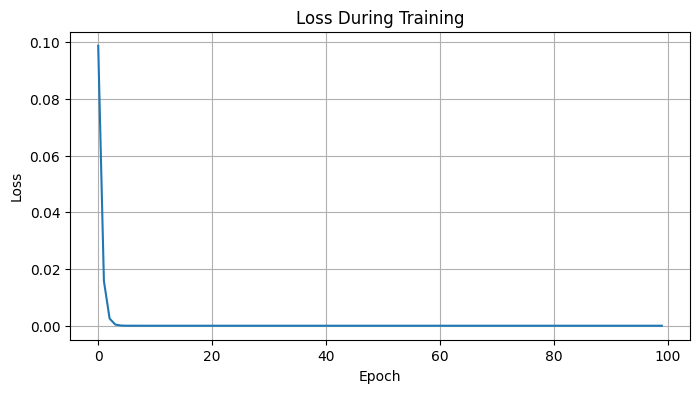

In [13]:
# Visualization
import matplotlib.pyplot as plt

losses = []

dense = Dense(2,1)

for epoch in range(100):

    pred = dense.forward(x)

    loss = np.mean(
        (pred-target)**2
    )

    losses.append(loss)

    grad = 2*(pred-target)

    dense.backward(grad)

    dense.update(0.05)
    
plt.figure(figsize=(8,4))

plt.plot(losses)

plt.title(
    "Loss During Training"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()